# PHSX 256 Topic 7: Graphical Output


## Setup


In [10]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

# Random generator for repeatability
rng = np.random.default_rng(123)

## Matplotlib Pyplot vs Object-Oriented (OO) Interfaces
### **Pyplot (stateful)**: a MATLAB-like, global-state interface via `matplotlib.pyplot as plt`.
- Works with a **current** Figure/Axes — functions like `plt.plot`, `plt.xlabel`, etc., mutate the active axes.
- Very concise for quick, single-axes plots.

### **Object-Oriented (OO)**: explicit **Figure**/**Axes** objects (recommended for complex figures, reproducibility, and libraries).
- You explicitly create and pass around objects: `fig, ax = plt.subplots(); ax.plot(...)`.
- Scales to **multiple axes**, complex layouts, 3D, sharing, and library-quality figures.
- Clearer control, fewer surprises with global state.

### Line plot: Simple Harmonic Oscillator (SHO)
SHO with amplitude $A$, angular frequency $\omega$, and phase $\phi$:
- $x(t) = A\cos(\omega t + \phi)$
- $v(t) = -A\omega\sin(\omega t + \phi)$

### Pyplot style

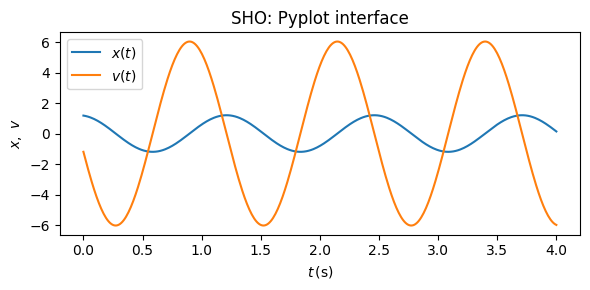

In [11]:
# SHO parameters and data
aA, omega, phi = 1.2, 2*np.pi*0.8, 0.2
T, N = 4.0, 400
t = np.linspace(0, T, N)
x = aA*np.cos(omega*t + phi)
v = -aA*omega*np.sin(omega*t + phi)

# Pyplot (stateful)
plt.figure(figsize=(6,3))
plt.plot(t, x, label=r'$x(t)$')
plt.plot(t, v, label=r'$v(t)$')
plt.xlabel(r'$t\,(\mathrm{s})$')
plt.ylabel(r'$x,\ v$')
plt.title('SHO: Pyplot interface')
plt.legend()
plt.tight_layout()


### OO style


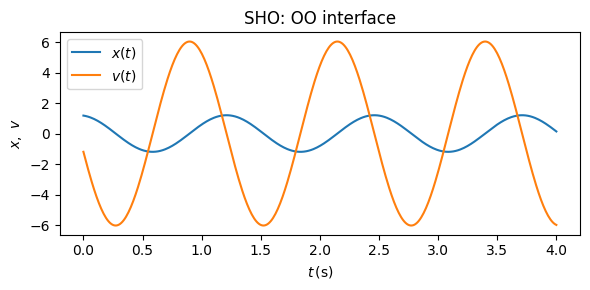

In [12]:
# OO interface
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(t, x, label=r'$x(t)$')
ax.plot(t, v, label=r'$v(t)$')
ax.set_xlabel(r'$t\,(\mathrm{s})$')
ax.set_ylabel(r'$x,\ v$')
ax.set_title('SHO: OO interface')
ax.legend()
fig.tight_layout()


### Projectile motion (line + scatter)
Under constant gravitational acceleration $\vec{a}=(0,-g)$ with $g=9.81\,\mathrm{m/s^2}$ and initial conditions $\vec{r}_0=(0,0)$, $\vec{v}_0=(v\cos\theta, v\sin\theta)$, the trajectory is
$\vec{r}(t)=\vec{r}_0+\vec{v}_0\,t+\tfrac{1}{2}\,\vec{a}\,t^2$.

#### Pyplot style


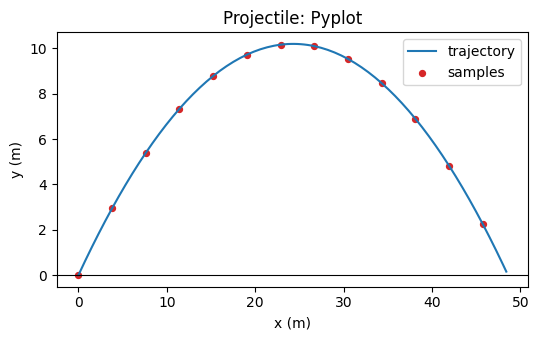

In [13]:
# Parameters
g = 9.81
v, th = 22.0, np.deg2rad(40)
r0 = np.array([0.0, 0.0])
v0 = np.array([v*np.cos(th), v*np.sin(th)])
a = np.array([0.0, -g])
Tsim, Ns = 4.5, 200
_t = np.linspace(0, Tsim, Ns)
r = r0 + v0*_t[:,None] + 0.5*a*(_t[:,None]**2)
valid = r[:,1] >= 0

# Pyplot
plt.figure(figsize=(5.5,3.5))
plt.plot(r[valid,0], r[valid,1], label='trajectory')
plt.scatter(r[valid,0][::10], r[valid,1][::10], s=18, c='tab:red', label='samples')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.title('Projectile: Pyplot')
plt.legend()
plt.tight_layout()

#### OO style

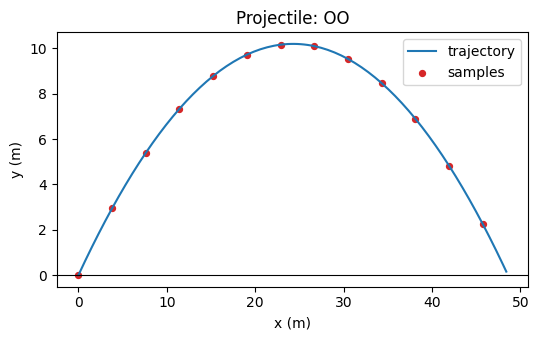

In [14]:
fig, ax = plt.subplots(figsize=(5.5,3.5))
ax.plot(r[valid,0], r[valid,1], label='trajectory')
ax.scatter(r[valid,0][::10], r[valid,1][::10], s=18, c='tab:red', label='samples')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Projectile: OO')
ax.legend(); fig.tight_layout()

## Cheat Sheet: Common Tasks in Both Interfaces

### Create a Figure
**Pyplot**
```python
plt.figure(figsize=(6,3))
```
**OO**
```python
fig = plt.figure(figsize=(6,3))
```

### Create Axes / Subplots
**Pyplot**
```python
plt.subplot(1, 1, 1)         # or
fig, ax = plt.subplots()     # returns objects but callable from pyplot style
```
**OO**
```python
fig, ax = plt.subplots()           # single Axes
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)  # grid
```

### Line Plot
**Pyplot**
```python
plt.figure(figsize=(6,3))
plt.plot(x, y, label='sin')
plt.legend(); plt.tight_layout()
```
**OO**
```python
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(x, y, label='sin')
ax.legend(); fig.tight_layout()
```

### Labels, Title, Legend (with LaTeX)
**Pyplot**
```python
plt.xlabel(r'$t\,(\mathrm{s})$')
plt.ylabel(r'$x,\ v$')
plt.title(r'SHO: $x(t)=A\cos(\omega t+\phi)$')
plt.legend()
```
**OO**
```python
ax.set_xlabel(r'$t\,(\mathrm{s})$')
ax.set_ylabel(r'$x,\ v$')
ax.set_title(r'SHO: $x(t)=A\cos(\omega t+\phi)$')
ax.legend()
```

### Image + Colorbar
**Pyplot**
```python
plt.figure(figsize=(5,4))
im = plt.imshow(V, origin='lower', extent=[-3,3,-3,3], cmap='viridis')
plt.colorbar(im, label=r'$V$')
plt.tight_layout()
```
**OO**
```python
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(V, origin='lower', extent=[-3,3,-3,3], cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$V$')
fig.tight_layout()
```

### Contour / Filled Contour
**Pyplot**
```python
plt.figure(figsize=(5,4))
cs = plt.contour(X, Y, V, levels=12, colors='k', linewidths=0.8)
cf = plt.contourf(X, Y, V, levels=20, cmap='plasma', alpha=0.85)
plt.clabel(cs, inline=True, fontsize=8)
plt.colorbar(cf, label=r'$V$')
```
**OO**
```python
fig, ax = plt.subplots(figsize=(5,4))
cs = ax.contour(X, Y, V, levels=12, colors='k', linewidths=0.8)
cf = ax.contourf(X, Y, V, levels=20, cmap='plasma', alpha=0.85)
ax.clabel(cs, inline=True, fontsize=8)
fig.colorbar(cf, ax=ax, label=r'$V$')
```

### 3D Surface (OO)
**OO only**
```python
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, V, cmap='viridis', linewidth=0)
fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label=r'$V$')
```

### Save Figure
**Pyplot**
```python
plt.savefig('figure_pyplot.png', dpi=300, bbox_inches='tight')
```
**OO**
```python
fig.savefig('figure_oo.png', dpi=300, bbox_inches='tight')
```

### Show Figure (not normally needed in Jupyter notebooks)
**Pyplot**
```python
plt.show()
```
**OO**
```python
plt.show()
```


## Quick anatomy: Figure, Axes, and Artists
The **Figure** is the top-level container. Inside it are one or more **Axes** (the plotting area). Most plotting functions act on an `Axes` object (e.g., `ax.plot`, `ax.scatter`).


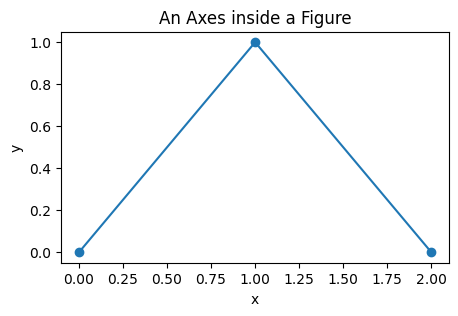

In [15]:
fig, ax = plt.subplots(figsize=(5,3))
ax.set_title('An Axes inside a Figure')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot([0,1,2], [0,1,0], marker='o');

## Switching Between Pyplot and OO Interfaces
Matplotlib's gca (Get Current Axes), gcf (Get Current Figure), sca (Set Current Axes), and plt.figure (Set Current Figure) are state-based functions in matplotlib.pyplot that manage which figure or axes receives plotting commands. They allow switching between active plotting areas in complex, multi-plot layouts. 

- `plt.gca()`: Get Current Axes. Retrieves the active plot/subplot.
- `plt.gcf()`: Get Current Figure. Retrieves the active window/canvas.
- `plt.sca(ax)`: Set Current Axes. Makes a specific Axes object the active one.
- `plt.figure(fig)`: Set Current Figure. Makes a specific Figure object the active one.
- `plt.clf()`: Clear Figure. Clears the entire active figure.
- `plt.cla()`: Clear Axes. Clears only the current active axes.

Current Figure ID: 1


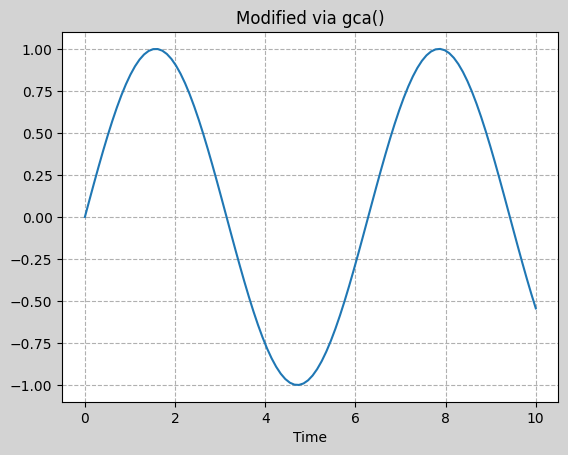

In [16]:
# 1. Create a simple plot without assigning variables
plt.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)))

# 2. Use gcf() to get the Figure and change the background color
fig = plt.gcf()
fig.set_facecolor('lightgrey')
print(f"Current Figure ID: {fig.number}")

# 3. Use gca() to get the Axes and modify the plot area
ax = plt.gca()
ax.set_title("Modified via gca()")
ax.grid(True, linestyle='--')
ax.set_xlabel("Time")

plt.show()


## Line plots — SHO position and velocity
For a simple harmonic oscillator with amplitude $A$, angular frequency $\omega$, and phase $\phi$:

- $x(t) = A\cos(\omega t + \phi)$
- $v(t) = -A\omega\sin(\omega t + \phi)$


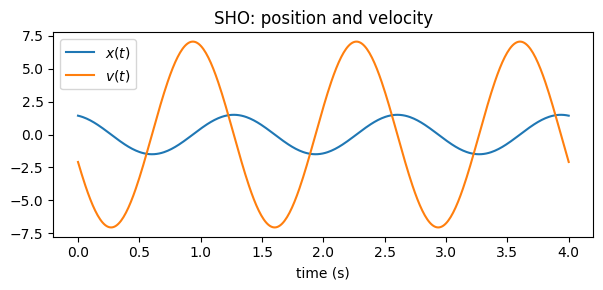

In [17]:
A, omega, phi = 1.5, 2*np.pi*0.75, 0.3
T = 4.0
N = 400
t = np.linspace(0, T, N)

x = A*np.cos(omega*t + phi)
v = -A*omega*np.sin(omega*t + phi)

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(t, x, label=r'$x(t)$')
ax.plot(t, v, label=r'$v(t)$')
ax.set_xlabel('time (s)')
ax.set_title('SHO: position and velocity')
ax.legend()
fig.tight_layout()


## Scatter plots — sampled projectile trajectory
Projectile under gravity with $\vec{a}=(0,-g)$ and 
$\vec{r}(t)=\vec{r}_0+\vec{v}_0\,t+\tfrac{1}{2}\,\vec{a}\,t^2$.
We plot scattered points along the trajectory.


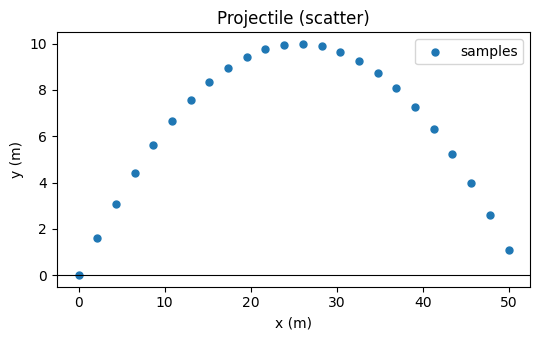

In [18]:

g = 9.81
r0 = np.array([0.0, 0.0])
v0 = np.array([18.0, 14.0])
T = 3.5
N = 30
t = np.linspace(0, T, N)
a = np.array([0.0, -g])

r = r0 + v0*t[:,None] + 0.5*a*(t[:,None]**2)
valid = r[:,1] >= 0

fig, ax = plt.subplots(figsize=(5.5,3.5))
ax.scatter(r[valid,0], r[valid,1], color='tab:blue', s=25, label='samples')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Projectile (scatter)')
ax.legend()
fig.tight_layout()

## Matplotlib Styles Reference


### Setup


In [41]:
from matplotlib import colors
from matplotlib.lines import Line2D

# Helper: draw a labeled swatch list (line or square)
def swatch_list(color_items, title='Colors', n_cols=3, patch_type='line'):
    n = len(color_items)
    n_cols = max(1, n_cols)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 0.6*n_rows+1), squeeze=False)
    fig.suptitle(title)
    for i, (name, cval) in enumerate(color_items):
        r, c = divmod(i, n_cols)
        ax = axes[r, c]
        ax.set_axis_off()
        if patch_type == 'square':
            ax.add_patch(plt.Rectangle((0,0), 1, 1, color=cval))
            ax.set_xlim(0,1); ax.set_ylim(0,1)
        else:
            ax.plot([0,1],[0.5,0.5], lw=6, color=cval)
            ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.text(0.02, 0.1, name, fontsize=10, color='black', transform=ax.transAxes)
    # hide unused
    for j in range(i+1, n_rows*n_cols):
        r, c = divmod(j, n_cols)
        axes[r, c].set_axis_off()
    fig.tight_layout()
    return fig

# Helper: scatter a grid of markers with labels
def marker_grid(markers, title='Markers', n_cols=10):
    n = len(markers)
    n_cols = max(1, n_cols)
    n_rows = int(np.ceil(n / n_cols))
    fig, ax = plt.subplots(figsize=(2.0*n_cols+2, 0.7*n_rows+2))
    ax.set_title(title)
    ax.set_axis_off()
    xs, ys, texts = [], [], []
    for idx, (mk, desc) in enumerate(markers):
        r = idx // n_cols
        c = idx % n_cols
        x = c + 1
        y = -(r + 1)
        ax.plot(x, y, marker=mk, markersize=9, color='tab:blue', linestyle='None')
        ax.text(x+0.25, y, f"'{mk}' {desc}", va='center', fontsize=8)
        xs.append(x); ys.append(y)
    ax.set_xlim(0, n_cols+2)
    ax.set_ylim(-(n_rows+1), 0)
    return fig


### Colors — ways to specify and what’s available

Matplotlib accepts many **color specifications**. Below are the most common:

- **Single-letter** codes (a.k.a. *Base*): `'b','g','r','c','m','y','k','w'`.
- **Named colors**:
  - **Tableau**: `'tab:blue','tab:orange',...` (color‑blind‑friendly defaults).
  - **CSS4** colors: many standard names, e.g., `'tomato'`, `'royalblue'`.
  - **XKCD** colors: prefixed with `'xkcd:'`, e.g., `'xkcd:leaf'`.
- **Grayscale strings**: `'0.0'` (black) to `'1.0'` (white).
- **Hex**: `'#RRGGBB'` or `'#RRGGBBAA'`.
- **RGB(A) tuples**: e.g., `(0.1, 0.2, 0.8)` or `(0.1, 0.2, 0.8, 0.7)`.
- **Default color cycle**: sequence used when no color is specified.


Counts:
 base: 8
 tableau: 10
 css4: 148
 xkcd: 949


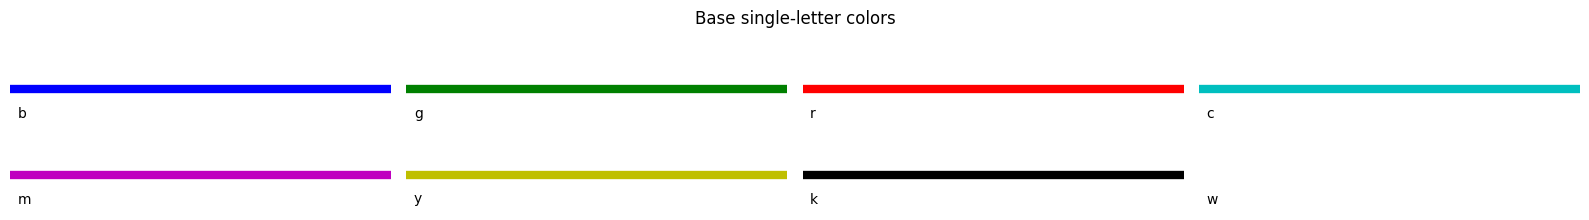

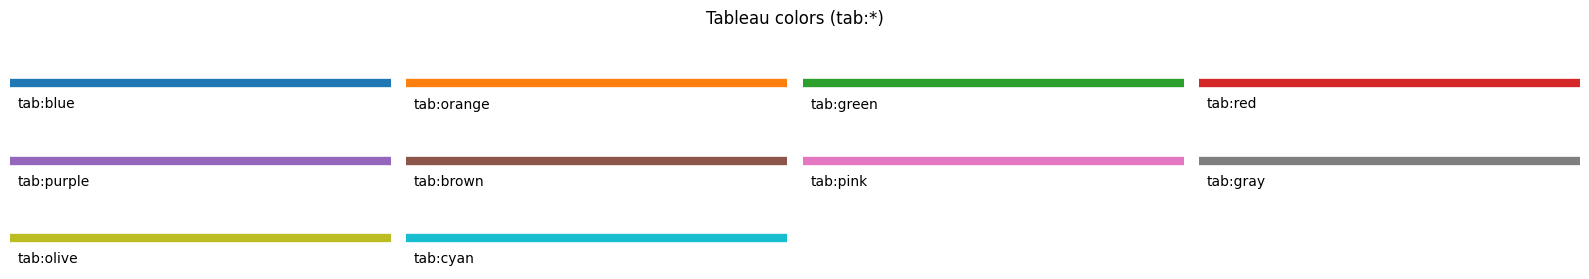

In [42]:

from matplotlib.colors import BASE_COLORS, TABLEAU_COLORS, CSS4_COLORS, XKCD_COLORS

print('Counts:')
print(' base:', len(BASE_COLORS))
print(' tableau:', len(TABLEAU_COLORS))
print(' css4:', len(CSS4_COLORS))
print(' xkcd:', len(XKCD_COLORS))

# Show single-letter base colors
base_list = list(BASE_COLORS.items())
swatch_list(base_list, title='Base single-letter colors', n_cols=4);

# Show Tableau colors (these match default cycle names)
tab_list = list(TABLEAU_COLORS.items())
swatch_list(tab_list, title='Tableau colors (tab:*)', n_cols=4);


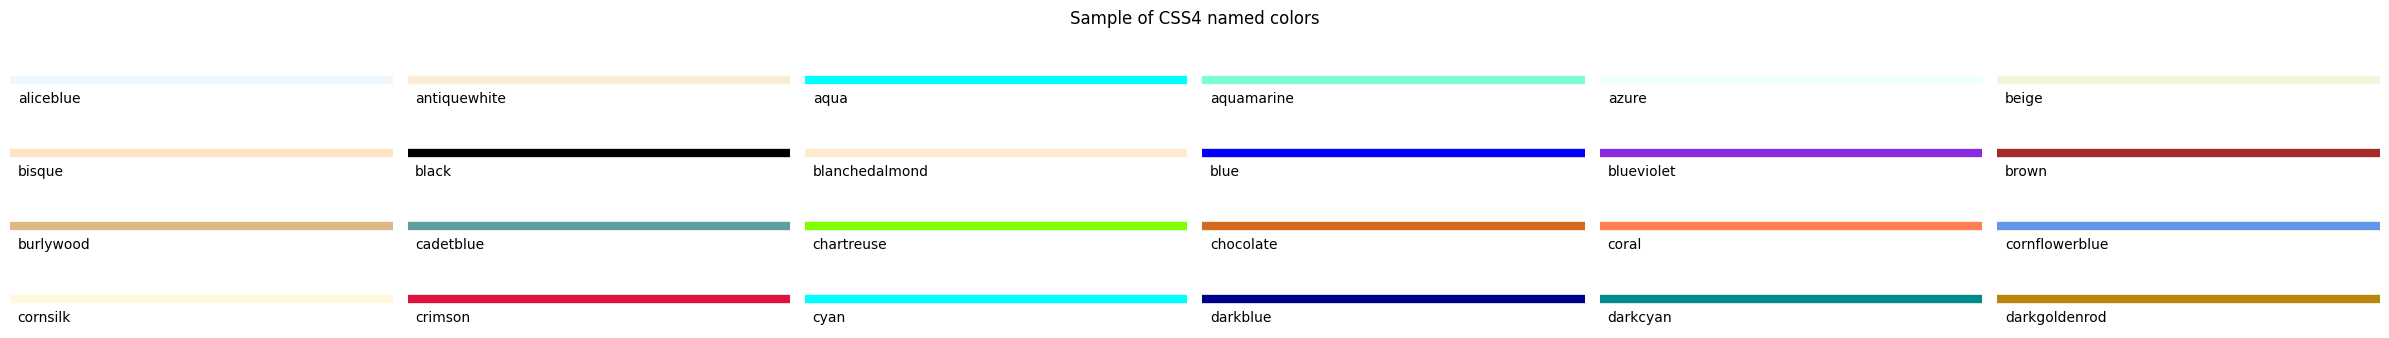

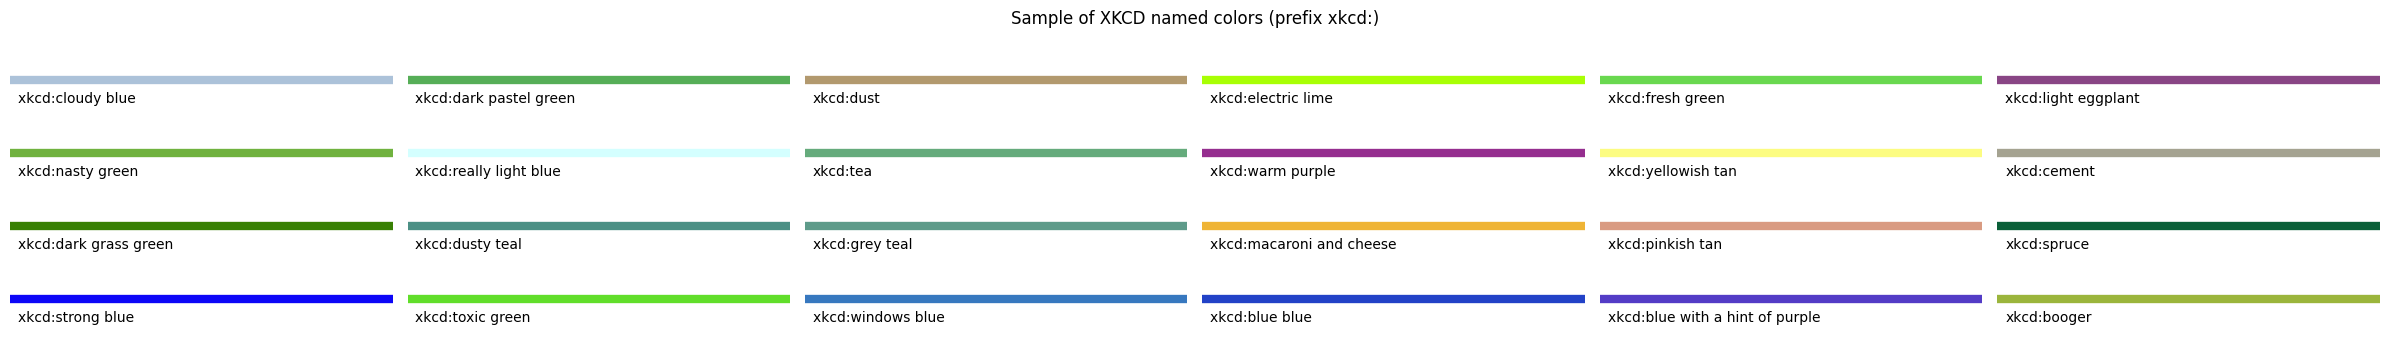

In [43]:

# Show a sample of CSS4 and XKCD colors (not all, they are numerous)
css_items = list(CSS4_COLORS.items())[:24]
xkcd_items = list(XKCD_COLORS.items())[:24]
swatch_list(css_items, title='Sample of CSS4 named colors', n_cols=6);
swatch_list(xkcd_items, title='Sample of XKCD named colors (prefix xkcd:)', n_cols=6);


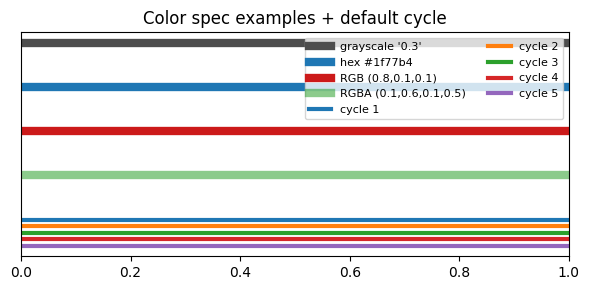

In [44]:

# Demonstrate grayscale, hex, RGB(A), and the default color cycle
fig, ax = plt.subplots(figsize=(6,3))
ax.plot([0,1],[1,1], color='0.3', lw=6, label="grayscale '0.3'")
ax.plot([0,1],[0.8,0.8], color='#1f77b4', lw=6, label="hex #1f77b4")
ax.plot([0,1],[0.6,0.6], color=(0.8,0.1,0.1), lw=6, label='RGB (0.8,0.1,0.1)')
ax.plot([0,1],[0.4,0.4], color=(0.1,0.6,0.1,0.5), lw=6, label='RGBA (0.1,0.6,0.1,0.5)')
# default color cycle demo
for i in range(5):
    ax.plot([0,1],[0.2-0.03*i,0.2-0.03*i], lw=3, label=f'cycle {i+1}')
ax.set_yticks([]); ax.set_xlim(0,1)
ax.legend(ncols=2, fontsize=8, loc='upper right'); ax.set_title('Color spec examples + default cycle')
fig.tight_layout();



### Line styles — built-ins and custom dashes

Built‑in styles (via `linestyle` or `ls`):
- `'-'` or `'solid'`
- `'--'` or `'dashed'`
- `'-.'` or `'dashdot'`
- `':'` or `'dotted'`

You can also use **custom dash patterns** with `linestyle=(offset, (on_1, off_1, on_2, off_2, ...))`.


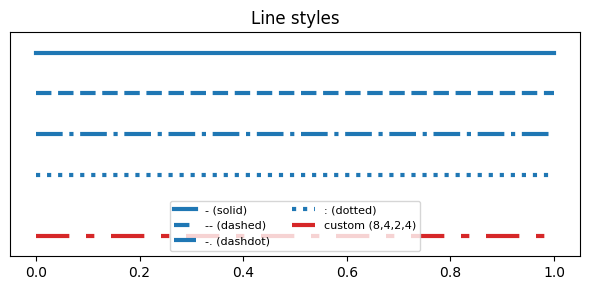

In [45]:

styles = [('-', 'solid'), ('--','dashed'), ('-.','dashdot'), (':','dotted')]
fig, ax = plt.subplots(figsize=(6,3))
for i, (s, name) in enumerate(styles):
    ax.plot([0,1], [1-i*0.2, 1-i*0.2], ls=s, lw=3, color='tab:blue', label=f"{s} ({name})")
# custom dash: offset 0, pattern 8 on, 4 off, 2 on, 4 off
ax.plot([0,1], [0.1, 0.1], ls=(0, (8,4,2,4)), lw=3, color='tab:red', label='custom (8,4,2,4)')
ax.set_ylim(0,1.1); ax.set_yticks([]); ax.set_title('Line styles')
ax.legend(fontsize=8, ncols=2, loc='lower center')
fig.tight_layout();



### Markers — complete list from `Line2D`

The marker options are maintained by Matplotlib. We read them **programmatically** from `matplotlib.lines.Line2D.markers` to stay current. Below is a labeled grid of **all supported markers** (except `None`/empty).


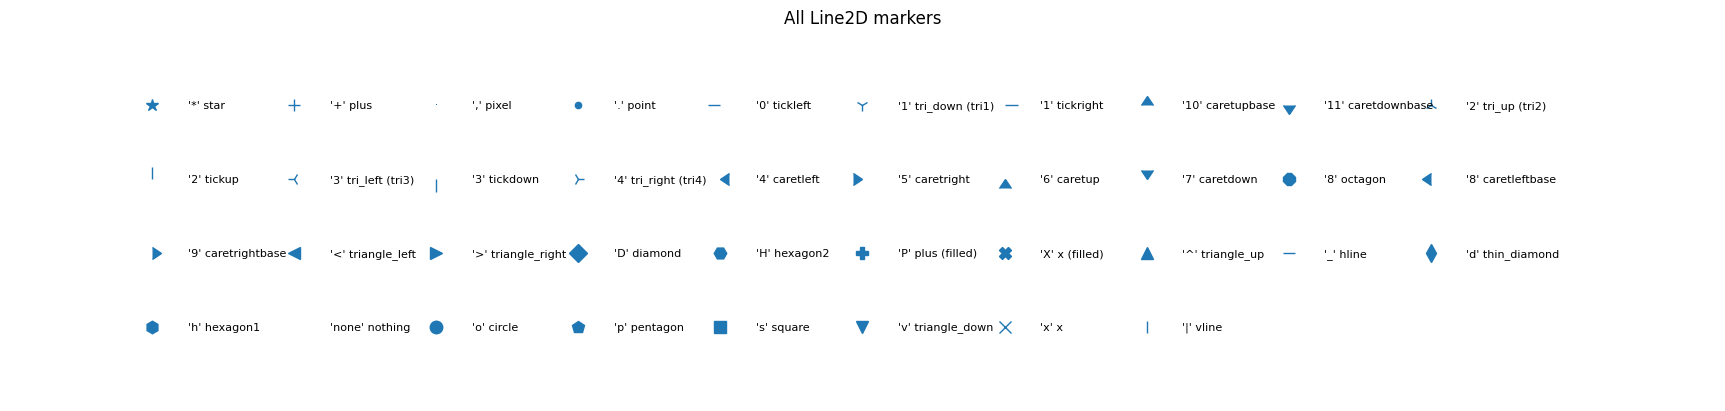

In [46]:

# Retrieve markers from Line2D
mk_dict = Line2D.markers.copy()
# Filter out None, 'None', ' ', ''
marker_items = []
for k, v in mk_dict.items():
    if k in [None, 'None', ' ', '']:
        continue
    # v is a Path or marker description; we'll show key and a friendly label
    desc = str(v)
    marker_items.append((k, desc))
# Sort by string of key for reproducibility
marker_items_sorted = sorted(marker_items, key=lambda t: str(t[0]))
# Build a simplified label (e.g., 'o: circle')
pretty = []
for mk, desc in marker_items_sorted:
    label = {
        '.':'point', ',':'pixel', 'o':'circle', 'v':'triangle_down', '^':'triangle_up', '<':'triangle_left', '>':'triangle_right',
        '1':'tri_down (tri1)', '2':'tri_up (tri2)', '3':'tri_left (tri3)', '4':'tri_right (tri4)', 's':'square', 'p':'pentagon',
        '*':'star', 'h':'hexagon1', 'H':'hexagon2', '+':'plus', 'x':'x', 'X':'x (filled)', 'D':'diamond', 'd':'thin_diamond',
        '|':'vline', '_':'hline', 'P':'plus (filled)', '8':'octagon'
    }.get(mk, desc)
    pretty.append((mk, label))

marker_grid(pretty, title='All Line2D markers', n_cols=10);


### SHO with line styles and colors
For the simple harmonic oscillator (unit mass and spring), $x(t)=A\cos(\omega t+\phi)$ and $v(t)=-A\,\omega\sin(\omega t+\phi)$. We plot both with distinct styles.


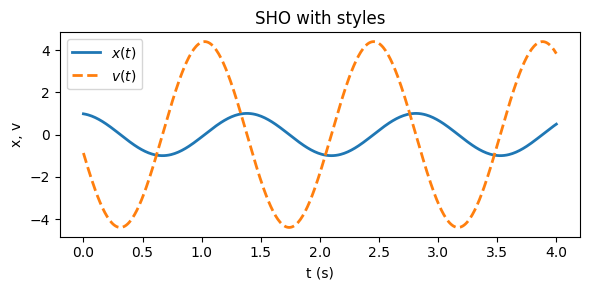

In [38]:

A, w, phi = 1.0, 2*np.pi*0.7, 0.2
T, N = 4.0, 400
t = np.linspace(0, T, N)
x = A*np.cos(w*t + phi)
v = -A*w*np.sin(w*t + phi)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(t, x, color='tab:blue', ls='-', lw=2, label=r'$x(t)$')
ax.plot(t, v, color='tab:orange', ls='--', lw=2, label=r'$v(t)$')
ax.set_xlabel('t (s)'); ax.set_ylabel('x, v'); ax.legend(); ax.set_title('SHO with styles')
fig.tight_layout();



### Projectile samples with marker types
Projectile under $\vec{a}=(0,-g)$; we scatter points at equal time intervals using different **markers**.


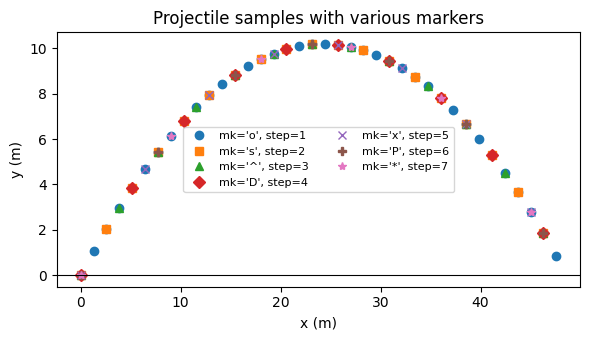

In [39]:

# Projectile points
g = 9.81
v, th = 22.0, np.deg2rad(40)
r0 = np.array([0.0, 0.0])
v0 = np.array([v*np.cos(th), v*np.sin(th)])
a = np.array([0.0, -g])
Tsim, Ns = 4.5, 60
t = np.linspace(0, Tsim, Ns)
r = r0 + v0*t[:,None] + 0.5*a*(t[:,None]**2)
mask = r[:,1] >= 0
R = r[mask]
markers = ['o','s','^','D','x','P','*']
fig, ax = plt.subplots(figsize=(6,3.5))
for i, mk in enumerate(markers):
    step = i+1
    pts = R[::step]
    ax.plot(pts[:,0], pts[:,1], ls='None', marker=mk, label=f"mk='{mk}', step={step}")
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.legend(ncols=2, fontsize=8)
ax.set_title('Projectile samples with various markers')
fig.tight_layout();



### Custom dash patterns
We compare custom dash sequences on a simple potential‑like curve $V(x)=\frac{1}{2}kx^2$.


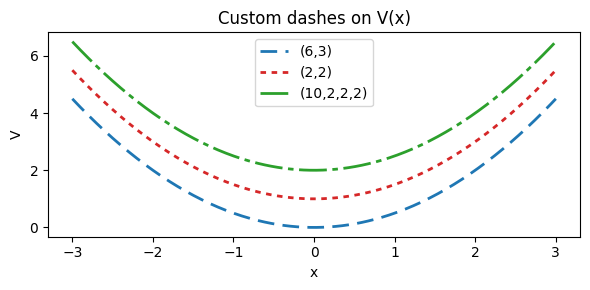

In [40]:

x = np.linspace(-3, 3, 300)
V = 0.5*x**2
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(x, V, color='tab:blue', ls=(0,(6,3)), lw=2, label='(6,3)')
ax.plot(x, V+1, color='tab:red', ls=(0,(2,2)), lw=2, label='(2,2)')
ax.plot(x, V+2, color='tab:green', ls=(0,(10,2,2,2)), lw=2, label='(10,2,2,2)')
ax.set_xlabel('x'); ax.set_ylabel('V'); ax.legend(); ax.set_title('Custom dashes on V(x)')
fig.tight_layout();



## Error bars — plotting measurements and uncertainty

Use `ax.errorbar(...)` for vertical (`yerr`) and horizontal (`xerr`) error bars. You can provide symmetric errors (scalar or 1D arrays) or **asymmetric** errors as a two-row array `[lower, upper]`. Style error bars with `fmt`, `ecolor`, `elinewidth`, and `capsize`. Error bars work on linear and logarithmic axes and alongside legends and shared axes.


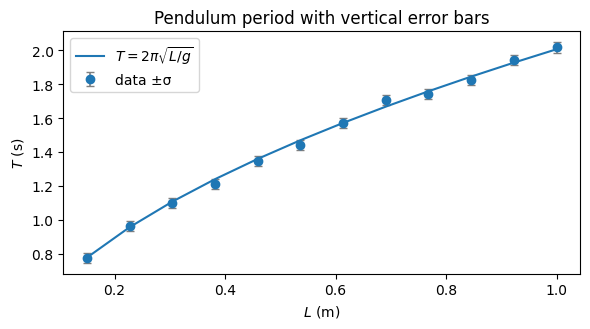

In [10]:
# Pendulum period with vertical error bars
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)
g = 9.81
L = np.linspace(0.15, 1.0, 12)
T_true = 2*np.pi*np.sqrt(L/g)
sigma_T = 0.03
T_meas = T_true + rng.normal(0, sigma_T, size=L.size)
fig, ax = plt.subplots(figsize=(6,3.4))
ax.errorbar(L, T_meas, yerr=sigma_T, fmt='o', capsize=3, ecolor='tab:gray', elinewidth=1.2, label='data ±σ')
ax.plot(L, T_true, color='tab:blue', label=r'$T=2\pi\sqrt{L/g}$')
ax.set_xlabel(r'$L\ (\mathrm{m})$'); ax.set_ylabel(r'$T\ (\mathrm{s})$')
ax.set_title('Pendulum period with vertical error bars')
ax.legend()
fig.tight_layout()

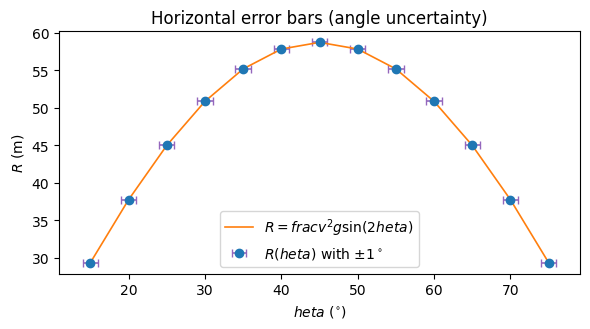

In [11]:
# Horizontal error bars: projectile range vs angle
import numpy as np
import matplotlib.pyplot as plt
g = 9.81; v = 24.0
th_deg = np.linspace(15, 75, 13)
th = np.deg2rad(th_deg)
R = v**2/g * np.sin(2*th)
sigma_th = 1.0  # degrees
xerr = sigma_th * np.ones_like(th_deg)
fig, ax = plt.subplots(figsize=(6,3.4))
ax.errorbar(th_deg, R, xerr=xerr, fmt='o', capsize=3, ecolor='tab:purple', elinewidth=1.2, label=r'$R(	heta)$ with $\pm 1^\circ$')
ax.plot(th_deg, R, lw=1.2, label=r'$R=	frac{v^2}{g}\sin(2	heta)$')
ax.set_xlabel(r'$	heta\ (^{\circ})$'); ax.set_ylabel(r'$R\ (\mathrm{m})$')
ax.set_title('Horizontal error bars (angle uncertainty)')
ax.legend()
fig.tight_layout()

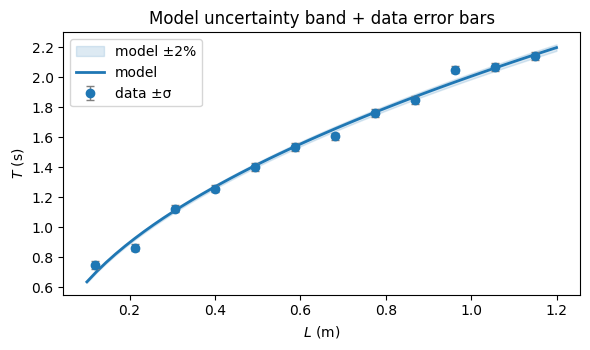

In [12]:
# Model uncertainty band with data error bars
import numpy as np
import matplotlib.pyplot as plt
g = 9.81
L = np.linspace(0.1, 1.2, 50)
T_model = 2*np.pi*np.sqrt(L/g)
T_lo = 2*np.pi*np.sqrt(L/(g*1.02))
T_hi = 2*np.pi*np.sqrt(L/(g*0.98))
rng = np.random.default_rng(3)
L_m = np.linspace(0.12, 1.15, 12)
T_true = 2*np.pi*np.sqrt(L_m/g)
T_meas = T_true + rng.normal(0, 0.025, size=L_m.size)
sigma_T = 0.025*np.ones_like(L_m)
fig, ax = plt.subplots(figsize=(6,3.6))
ax.fill_between(L, T_lo, T_hi, color='tab:blue', alpha=0.15, label='model ±2%')
ax.plot(L, T_model, color='tab:blue', lw=2, label='model')
ax.errorbar(L_m, T_meas, yerr=sigma_T, fmt='o', capsize=3, ecolor='tab:gray', elinewidth=1.0, label='data ±σ')
ax.set_xlabel(r'$L\ (\mathrm{m})$'); ax.set_ylabel(r'$T\ (\mathrm{s})$')
ax.set_title('Model uncertainty band + data error bars')
ax.legend()
fig.tight_layout()


## Histograms — distribution of projectile ranges
Simulate many projectiles with random launch angles and plot a histogram of **range** values.


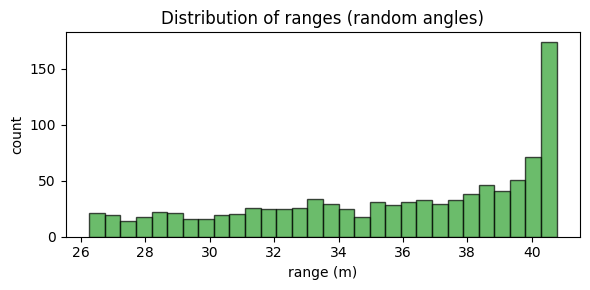

In [13]:
rng = np.random.default_rng(42)
P = 1000
speeds = 20.0
angles = np.deg2rad(rng.uniform(20, 70, size=P))

v0s = np.stack([speeds*np.cos(angles), speeds*np.sin(angles)], axis=1)
ranges = []
for v0 in v0s:
    tf = 2*v0[1]/g  # time to return to y=0 when y0=0
    ranges.append(v0[0]*tf)

ranges = np.array(ranges)

fig, ax = plt.subplots(figsize=(6,3))
ax.hist(ranges, bins=30, color='tab:green', edgecolor='black', alpha=0.7)
ax.set_xlabel('range (m)')
ax.set_ylabel('count')
ax.set_title('Distribution of ranges (random angles)')
fig.tight_layout()


## Image plots — 2D potential $V(x,y)=\tfrac{1}{2}k(x^2+y^2)$
Use `imshow` to present scalar fields as images (with colormap and colorbar). Set `extent` and `origin` for axis labels.


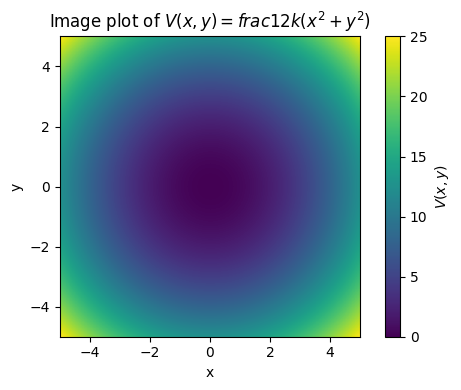

In [14]:
x = np.linspace(-5, 5, 21)
y = np.linspace(-5, 5, 21)
X, Y = np.meshgrid(x, y, indexing='xy')
k = 1.0
V = 0.5*k*(X**2 + Y**2)

fig, ax = plt.subplots(figsize=(5.5,4))
im = ax.imshow(V, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='viridis', interpolation='nearest')
cb = fig.colorbar(im, ax=ax, label=r'$V(x,y)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Image plot of $V(x,y)=\frac{1}{2}k(x^2+y^2)$')
fig.tight_layout();


## Contour plots — equipotential lines for $V(x,y)$
Contour lines (and filled contours) are useful for visualizing level sets of scalar fields.


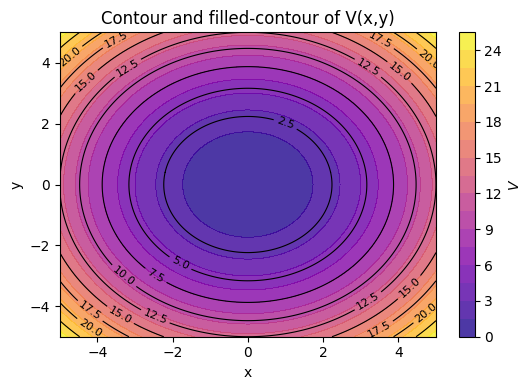

In [15]:
fig, ax = plt.subplots(figsize=(5.5,4))
cs = ax.contour(X, Y, V, levels=10, colors='k', linewidths=0.8)
cf = ax.contourf(X, Y, V, levels=20, cmap='plasma', alpha=0.8)
ax.clabel(cs, inline=True, fontsize=8)
fig.colorbar(cf, ax=ax, label=r'$V$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Contour and filled-contour of V(x,y)')
fig.tight_layout();


## 3D surface plots — potential surface $V(x,y)$
Use `Axes3D` with `plot_surface` to render a 3D surface of $V(x,y)$.


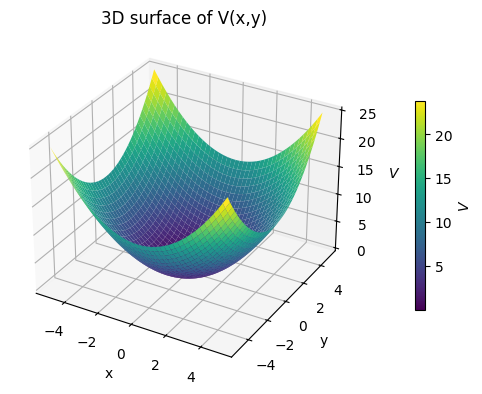

In [16]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, V, cmap='viridis', linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label=r'$V$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel(r'$V$')
ax.set_title('3D surface of V(x,y)')
fig.tight_layout();

## Axis scales — linear vs logarithmic

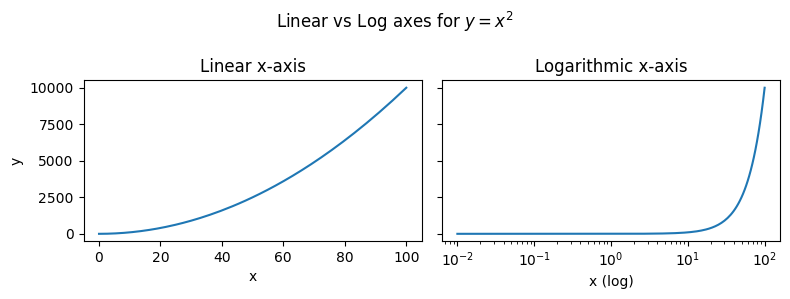

In [17]:
x = np.logspace(-2, 2, 200)
y = x**2

fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True)
axes[0].plot(x, y)
axes[0].set_title('Linear x-axis')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].plot(x, y)
axes[1].set_xscale('log')
axes[1].set_title('Logarithmic x-axis')
axes[1].set_xlabel('x (log)')

fig.suptitle(r'Linear vs Log axes for $y=x^2$')
fig.tight_layout();


### When to use linear, semilog, and log–log plots

- **Linear–linear** axes: Use when variables change roughly **linearly** or by a constant offset. Example: position under **constant velocity**; small segments of smooth curves.
- **Semilog** (e.g., log–y vs linear–x): Use when one variable changes **exponentially** with the other. The model $y= y_0\,e^{-\gamma x}$ appears as a **straight line** on a semilog plot of $\ln y$ vs $x$ with slope $-\gamma$.
- **Log–log**: Use when one variable follows a **power law** in another, $y= C\,x^{n}$. A log–log plot of $\log y$ vs $\log x$ is a straight line with slope $n$ and intercept $\log C$.

**Matplotlib scale controls**
- Pyplot: `plt.xscale('log')`, `plt.yscale('log')`, `plt.semilogx(...)`, `plt.semilogy(...)`, `plt.loglog(...)`
- OO: `ax.set_xscale('log')`, `ax.set_yscale('log')`

> **Important:** Log axes require **positive** data. Mask or drop nonpositive values, or shift your variable appropriately when that makes physical sense.


### Semilog example — damped oscillator envelope (exponential decay)

The lightly damped oscillator amplitude envelope behaves like an exponential: $|x(t)| = A\,e^{-\gamma t}$. This is a classic case for a **semilog-$y$** plot (linear $x$, log $y$), which turns the curve into a straight line with slope $-\gamma$.

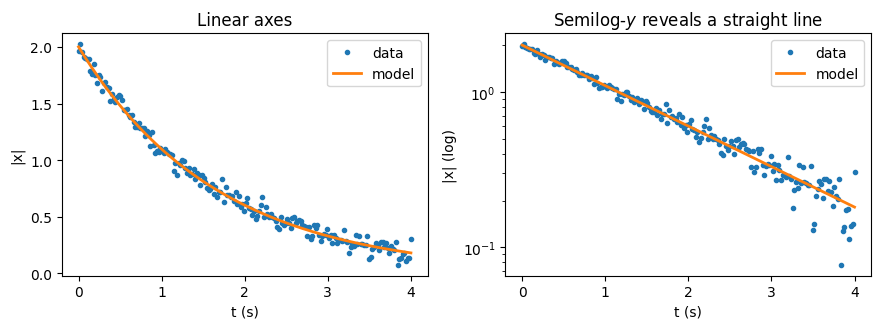

In [18]:
# Parameters and noisy measurements (positive)
A, gamma = 2.0, 0.6
Tmax, N = 4.0, 200
t = np.linspace(0, Tmax, N)
true_env = A*np.exp(-gamma*t)
noise = rng.normal(0.0, 0.05, size=N)
y = np.clip(true_env + noise, 1e-6, None)  # ensure positive

# Plot: linear vs semilog-y
fig, axes = plt.subplots(1,2, figsize=(9,3.4), sharex=True)
axes[0].plot(t, y, 'o', ms=3, label='data')
axes[0].plot(t, true_env, lw=2, label='model')
axes[0].set_xlabel('t (s)'); axes[0].set_ylabel('|x|')
axes[0].set_title('Linear axes')
axes[0].legend()

axes[1].plot(t, y, 'o', ms=3, label='data')
axes[1].plot(t, true_env, lw=2, label='model')
axes[1].set_yscale('log')
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('|x| (log)')
axes[1].set_title('Semilog-$y$ reveals a straight line')
axes[1].legend()
fig.tight_layout()


### Log–log example — small-angle pendulum period vs length (power law)

For a simple pendulum at small angles, $T=2\pi\sqrt{\dfrac{L}{g}}$. Thus $T\propto L^{1/2}$, a **power law** in $L$. A **log–log** plot of $T$ vs $L$ should be a line with slope $\frac{1}{2}$.


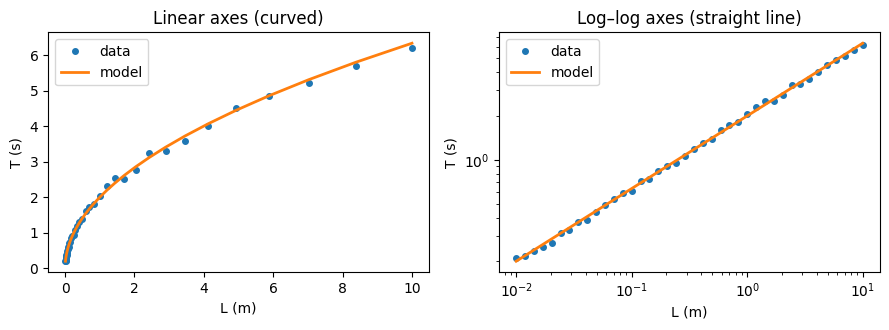

In [19]:
# Generate synthetic measurements
g = 9.81
L = np.logspace(-2, 1, 40)
T_true = 2*np.pi*np.sqrt(L/g)
T_meas = T_true * (1.0 + rng.normal(0, 0.03, size=L.size))

# Linear vs log-log
fig, axes = plt.subplots(1,2, figsize=(9,3.4), sharey=False)
axes[0].plot(L, T_meas, 'o', ms=4, label='data')
axes[0].plot(L, T_true, lw=2, label='model')
axes[0].set_xlabel('L (m)'); axes[0].set_ylabel('T (s)')
axes[0].set_title('Linear axes (curved)'); axes[0].legend()

axes[1].loglog(L, T_meas, 'o', ms=4, label='data')
axes[1].loglog(L, T_true, lw=2, label='model')
axes[1].set_xlabel('L (m)'); axes[1].set_ylabel('T (s)')
axes[1].set_title('Log–log axes (straight line)'); axes[1].legend()
fig.tight_layout()


### Log–log example — gravitational potential magnitude $|U(r)|\propto r^{-1}$

With $U(r)=-\dfrac{GMm}{r}$, the magnitude $|U(r)|=\dfrac{GMm}{r}$ follows a **power law** with exponent $-1$. A **log–log** plot of $|U|$ vs $r$ should be a straight line with slope $-1$.


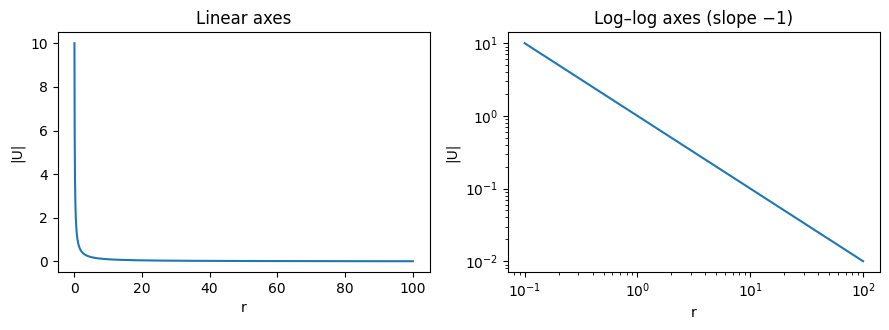

In [20]:
GMm = 1.0
r = np.logspace(-1, 2, 200)
Uabs = GMm / r

fig, axes = plt.subplots(1,2, figsize=(9,3.4), sharey=False)
axes[0].plot(r, Uabs)
axes[0].set_xlabel('r'); axes[0].set_ylabel('|U|')
axes[0].set_title('Linear axes')

axes[1].loglog(r, Uabs)
axes[1].set_xlabel('r'); axes[1].set_ylabel('|U|')
axes[1].set_title('Log–log axes (slope −1)')
fig.tight_layout()


### Log–log example — free-fall distance $s(t)=	\frac{1}{2}gt^{2}$ (quadratic)

From rest, $s(t)=\frac{1}{2}gt^2$ so $s\propto t^{2}$, a **power law** with exponent $2$. On a **log–log** plot of $s$ vs $t$, the slope should be $2$.


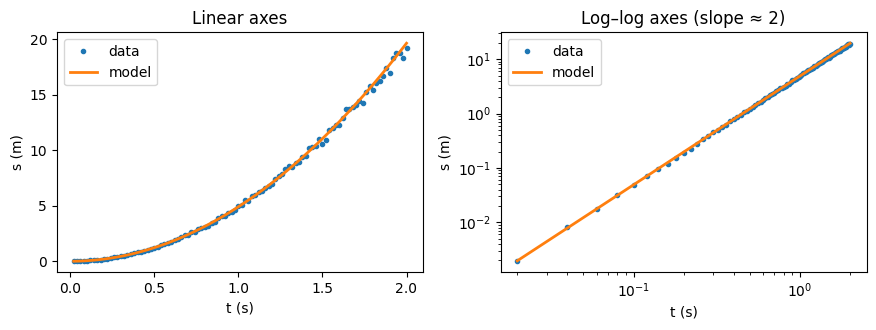

In [21]:
# Data
g = 9.81
t = np.linspace(0.02, 2.0, 100)  # start above zero for log
s = 0.5*g*t**2
s_meas = s*(1 + rng.normal(0, 0.02, size=t.size))

fig, axes = plt.subplots(1,2, figsize=(9,3.4), sharey=False)
axes[0].plot(t, s_meas, 'o', ms=3, label='data')
axes[0].plot(t, s, lw=2, label='model')
axes[0].set_xlabel('t (s)'); axes[0].set_ylabel('s (m)')
axes[0].set_title('Linear axes'); axes[0].legend()

axes[1].loglog(t, s_meas, 'o', ms=3, label='data')
axes[1].loglog(t, s, lw=2, label='model')
axes[1].set_xlabel('t (s)'); axes[1].set_ylabel('s (m)')
axes[1].set_title('Log–log axes (slope ≈ 2)'); axes[1].legend()
fig.tight_layout()


### How to set scales — Pyplot vs OO quick demo

- **Pyplot**: `plt.semilogy(x, y)`, `plt.semilogx(x, y)`, `plt.loglog(x, y)` or `plt.yscale('log')`, `plt.xscale('log')`.
- **OO**: `ax.semilogy(x, y)`, `ax.semilogx(x, y)`, `ax.loglog(x, y)` or `ax.set_yscale('log')`, `ax.set_xscale('log')`.


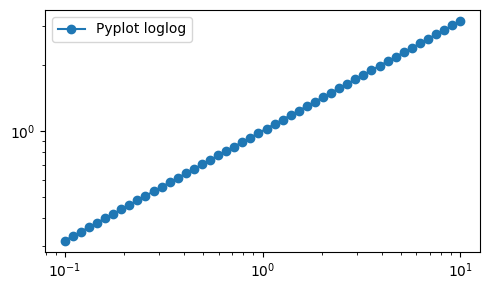

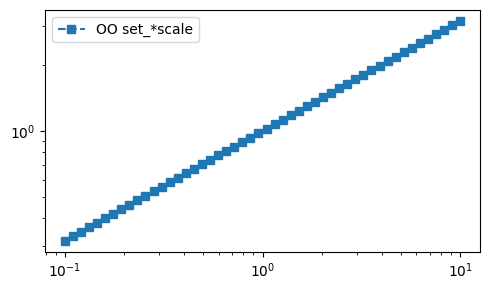

In [22]:
# Tiny demo comparing styles
x = np.logspace(-1, 1, 50)
y = x**0.5

# Pyplot
plt.figure(figsize=(5,3))
plt.loglog(x, y, 'o-', label='Pyplot loglog')
plt.legend(); plt.tight_layout()

# OO
fig, ax = plt.subplots(figsize=(5,3))
ax.set_xscale('log'); ax.set_yscale('log')
ax.plot(x, y, 's--', label='OO set_*scale')
ax.legend(); fig.tight_layout()


### Tips and pitfalls for log plots

- **Data must be positive** on any axis you set to log. Use a **mask**: e.g., `mask = (y > 0)` then plot `x[mask], y[mask]`.
- Avoid plotting **zeros** on log axes; start at a small positive value or use physical shifts if justified.
- For **straight‑line fits** on log or semilog axes, fit the **transformed data** (e.g., `np.log(y)` vs `x`, or `np.log(y)` vs `np.log(x)`).
- Use `ax.grid(True, which='both')` and optionally `ax.minorticks_on()` to make the structure clear.



### Practice problems

**Problem 1 — Exponential decay on semilog.**  
A damped signal has envelope $y(t)=y_0\,e^{-\gamma t}$.  
- Create noisy data for $y(t)$ on $t\in[0,T]$ and plot on linear and **semilog-$y$** axes.  
- Estimate $\gamma$ from a **linear fit** to $\ln y$ vs $t$.

**Problem 2 — Power law slope on log–log.**  
For free fall from rest, $s(t)=	frac{1}{2}g t^2$.  
- Plot $s$ vs $t$ on **log–log** axes and compute the slope by fitting $\ln s$ vs $\ln t$.  
- Compare to the expected value $2$.

**Problem 3 — Pendulum period vs length.**  
Small-angle pendulum relation $T=2\pi\sqrt{L/g}$ suggests a slope of $\frac{1}{2}$ on **log–log** axes.  
- Generate synthetic $(L,T)$ data with small noise.  
- Plot on linear and log–log axes; compute the **log–log slope**.

**Problem 4 — Inverse power trend.**  
Gravitational potential magnitude $|U(r)|=\dfrac{GMm}{r}$.  
- Plot $|U|$ vs $r$ on linear and log–log axes.  
- Demonstrate that the slope on log–log is near $-1$.



### Summary
- Use **linear** axes for roughly linear relationships; use **semilog** when you expect **exponential** behavior; use **log–log** for **power laws**.  
- Slopes on semilog reveal **decay rates** (e.g., $-\gamma$); slopes on log–log reveal **exponents** (e.g., $n$ in $y\propto x^{n}$).  
- In Matplotlib, switch scales with `set_xscale('log')` / `set_yscale('log')` or convenience functions `semilogx/semilogy/loglog`.



## Legends, multiple plots, and LaTeX in labels
Plot $x(t)$ and $v(t)$ for the SHO on the same Axes with a legend and LaTeX labels.


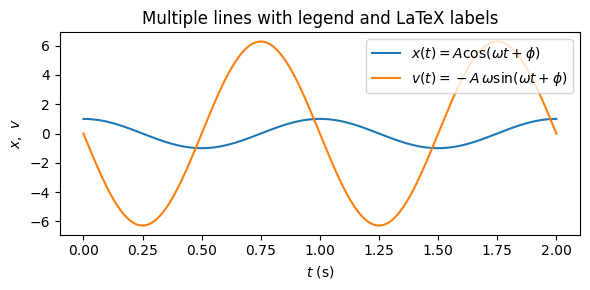

In [23]:
A, omega, phi = 1.0, 2*np.pi, 0.0
T = 2.0
N = 300
t = np.linspace(0, T, N)

x = A*np.cos(omega*t + phi)
v = -A*omega*np.sin(omega*t + phi)

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(t, x, label=r'$x(t)=A\cos(\omega t+\phi)$')
ax.plot(t, v, label=r'$v(t)=-A\,\omega\sin(\omega t+\phi)$')
ax.set_xlabel(r'$t$ (s)')
ax.set_ylabel(r'$x,\ v$')
ax.legend(loc='upper right', frameon=True)
ax.set_title('Multiple lines with legend and LaTeX labels')
fig.tight_layout();


## Multiple subplots and shared axes
Use `plt.subplots` to create grids of Axes. Sharing axes (`sharex`, `sharey`) helps align scales across plots.


Text(0.5, 0.98, 'Projectile trajectories (shared axes)')

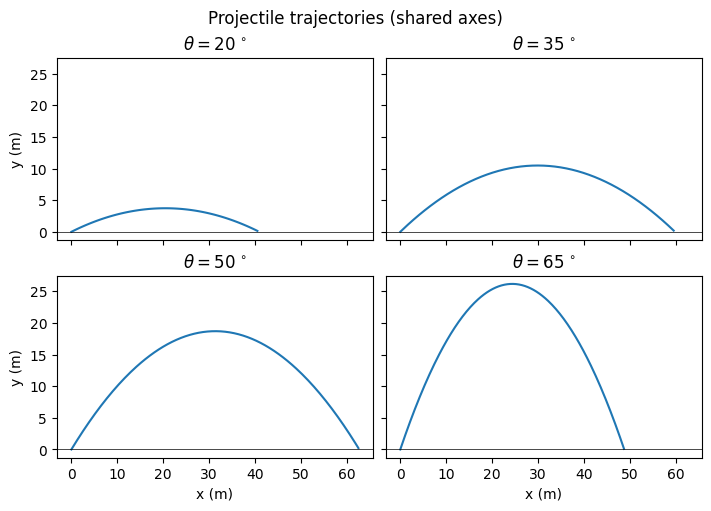

In [24]:
# Four different projectile angles, shared axes
g = 9.81
r0 = np.array([0.0, 0.0])
angles = np.deg2rad([20, 35, 50, 65])
v = 25.0

fig, axes = plt.subplots(2, 2, figsize=(7,5), sharex=True, sharey=True, constrained_layout=True)
for ax, th in zip(axes.ravel(), angles):
    v0 = np.array([v*np.cos(th), v*np.sin(th)])
    t = np.linspace(0, 6, 300)
    r = r0 + v0*t[:,None] + 0.5*np.array([0,-g])*(t[:,None]**2)
    valid = r[:,1] >= 0
    ax.plot(r[valid,0], r[valid,1])
    ax.set_title(fr'$\theta={np.rad2deg(th):.0f}\,^\circ$')
    ax.axhline(0, color='k', lw=0.5)

for ax in axes[-1]:
    ax.set_xlabel('x (m)')
for ax in axes[:,0]:
    ax.set_ylabel('y (m)')

fig.suptitle('Projectile trajectories (shared axes)')
# Using constrained_layout=True above manages spacing automatically.


## Plot element spacing: `tight_layout`, `constrained_layout`, and `subplots_adjust`
- `fig.tight_layout()` automatically adjusts spacing among elements.
- `constrained_layout=True` (when creating the Figure) also helps layout.
- `fig.subplots_adjust(left=..., right=..., top=..., bottom=..., wspace=..., hspace=...)` allows manual control.


Text(0.5, 0.98, 'Manual spacing with subplots_adjust')

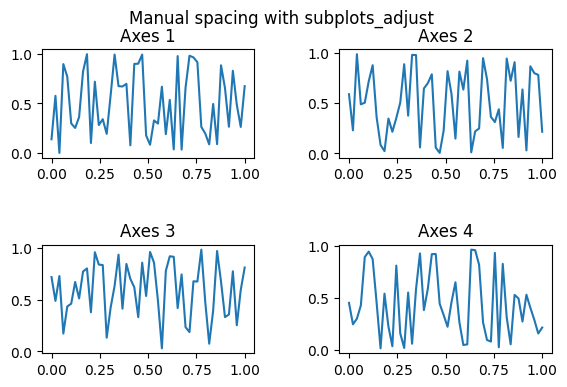

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(6,4))
for i, ax in enumerate(axes.ravel(), 1):
    ax.plot(np.linspace(0,1,50), np.random.rand(50))
    ax.set_title(f'Axes {i}')

# Manually adjust spacing
fig.subplots_adjust(wspace=0.4, hspace=0.8, left=0.1, right=0.95, top=0.88, bottom=0.12)
fig.suptitle('Manual spacing with subplots_adjust')


## Saving plots to file
Use `plt.savefig('filename.png', dpi=300, bbox_inches='tight')`. Call **before** `plt.show()` if using the stateful API.


Saved: saving_example.png and saving_example.pdf


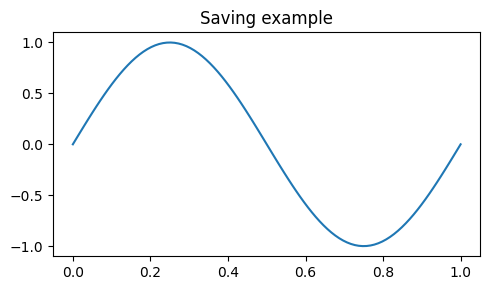

In [26]:
# Example: save a figure to PNG and PDF
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(np.linspace(0,1,100), np.sin(2*np.pi*np.linspace(0,1,100)))
ax.set_title('Saving example')
fig.tight_layout()
fig.savefig('saving_example.png', dpi=300, bbox_inches='tight')
fig.savefig('saving_example.pdf', bbox_inches='tight')
print('Saved: saving_example.png and saving_example.pdf')


## Combining multiple plots in one figure (asymmetric layouts)
Use `GridSpec` to create more complex layouts: a wide plot on top and two smaller plots below.


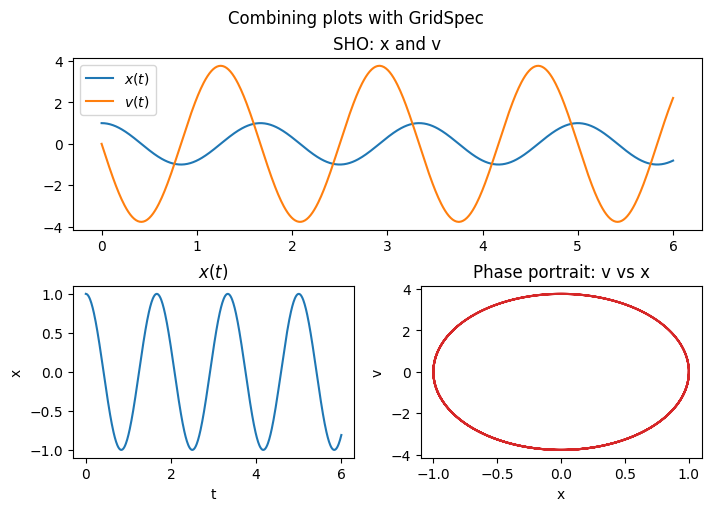

In [27]:
import matplotlib.gridspec as gridspec

# Sample data (SHO)
A, omega, phi = 1.0, 2*np.pi*0.6, 0.0
T = 6.0
N = 600
t = np.linspace(0, T, N)
x = A*np.cos(omega*t + phi)
v = -A*omega*np.sin(omega*t + phi)

fig = plt.figure(figsize=(7,5), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)
ax_top = fig.add_subplot(gs[0, :])
ax_bl  = fig.add_subplot(gs[1, 0])
ax_br  = fig.add_subplot(gs[1, 1])

# Top: both x and v
ax_top.plot(t, x, label=r'$x(t)$')
ax_top.plot(t, v, label=r'$v(t)$')
ax_top.legend(); ax_top.set_title('SHO: x and v')

# Bottom-left: x(t)
ax_bl.plot(t, x, color='tab:blue')
ax_bl.set_title(r'$x(t)$')
ax_bl.set_xlabel('t'); ax_bl.set_ylabel('x')

# Bottom-right: v(x) phase portrait
ax_br.plot(x, v, color='tab:red')
ax_br.set_title('Phase portrait: v vs x')
ax_br.set_xlabel('x'); ax_br.set_ylabel('v')

fig.suptitle('Combining plots with GridSpec');


## Practice problems

**Problem 1 — SHO line plot with logarithmic axis (amplitude envelope).**  
Consider a **lightly damped** oscillator with $x(t)=A\,e^{-\gamma t}\cos(\omega t+\phi)$.  
- Generate $x(t)$ for chosen $A,\ \gamma,\ \omega,\ \phi$ and $t$ over several periods.  
- Plot $x(t)$ with a **linear** time axis.  
- On a separate Axes, plot $|x(t)|$ on a **semilog-$y$** scale using `ax.set_yscale('log')`.  
- Add LaTeX labels and a legend.

**Problem 2 — Projectile trajectories with shared axes.**  
Under $\vec{a}=(0,-g)$ and $g=9.81$, the trajectory is $\vec{r}(t)=\vec{r}_0+\vec{v}_0\,t+\tfrac{1}{2}\,\vec{a}\,t^2$.  
- Create subplots for four different launch angles with **shared axes**.  
- Draw the ground line $y=0$.  
- Add titles showing the angle using LaTeX, e.g., $\theta=45^\circ$.

**Problem 3 — Histogram of energies.**  
For projectiles of mass $m$ and speeds $v$, the kinetic energy is $K=\tfrac{1}{2}m v^2$.  
- Sample $v$ from a distribution (e.g., uniform or normal, clipped to $v>0$).  
- Compute $K$ and plot a histogram with labeled axes and title in LaTeX.

**Problem 4 — Image and contour of a 2D potential.**  
For $V(x,y)=\tfrac{1}{2}k(x^2+y^2)+\varepsilon\,xy$,  
- Create a grid with `np.meshgrid`.  
- Plot both an **image** (`imshow`) and **contours** (`contour`, `contourf`) with the same `extent`.  
- Add a colorbar label $V$ and LaTeX axis labels.

**Problem 5 — 3D surface of a potential.**  
For $V(x,y)=\tfrac{1}{2}k(x^2+y^2)$,  
- Use a 3D Axes to render a **surface plot**.  
- Label axes with LaTeX and use an appropriate colormap.  
- Save the figure as both PNG and PDF.

**Problem 6 — Combining plots and spacing controls.**  
- Create a figure with **three** subplots (top spanning two columns, two on the bottom row) using `GridSpec`.  
- Demonstrate `tight_layout()`, `constrained_layout=True`, or `subplots_adjust(...)`.  
- Include a legend and LaTeX labels.
